# AL2002 - Artificial Intelligence Lab
## Track C: Student Performance Dataset

**Dataset:** Student Performance Prediction (UCI)

**Kaggle Keyword:** `student performance prediction UCI`

**Members:** `24F-0779(Muhammad Ans Rizwan),24F-0525(Khalil),24F-0785(Shaheer Hayat)`

---
# PHASE 1: Python and Data Foundation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections
import heapq
import random
import math
import copy

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Check working directory and Python path
import os
import sys

print(f"Current working directory: {os.getcwd()}")
print(f"Files in current directory: {os.listdir('.')}")


Current working directory: /home/anso/University/CODE/AI/Project
Files in current directory: ['.vscode', 'AL2002_Lab_Manual.pdf', '.venv', 'AI_PROJECT_TRACK_C.ipynb', 'student-mat.csv']


In [3]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

## Step 2 & 3: Load and Inspect the Dataset

In [ ]:
import os
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/student-mat.csv', sep=';')
print('Loaded successfully')
print(f'Shape: {df.shape}')
print(f'Data types sample:\n{df.dtypes.head(10)}')


Loaded successfully
Shape: (395, 33)
Data types sample:
school     object
sex        object
age         int64
address    object
famsize    object
Pstatus    object
Medu        int64
Fedu        int64
Mjob       object
Fjob       object
dtype: object


In [ ]:
display(df.head(10))

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [ ]:
# Load dataset - tries both math and portuguese CSVs common in UCI student dataset
import os

data_folder = '/content/student-mat.csv'

# Try common filenames
for fname in ['student-mat.csv', 'student-por.csv', 'student.csv']:
    fpath = os.path.join(data_folder, fname)
    if os.path.exists(fpath):
        df = pd.read_csv(fpath, sep=';')
        print(f'Loaded: {fname}')
        break
else:
    # Fallback: try comma separator
    for fname in ['student-mat.csv', 'student-por.csv', 'student.csv']:
        fpath = os.path.join(data_folder, fname)
        if os.path.exists(fpath):
            df = pd.read_csv(fpath)
            print(f'Loaded: {fname}')
            break
    else:
        print('ERROR: No dataset file found. Place CSV in track_c_education/ folder.')

# Task 1: First 10 rows
print('\n--- First 10 Rows ---')
display(df.head(10))

ERROR: No dataset file found. Place CSV in track_c_education/ folder.

--- First 10 Rows ---


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [ ]:
# Task 2: Shape
print(f'Shape: {df.shape[0]} rows, {df.shape[1]} columns')

# Task 3: Data types
print('\n--- Data Types ---')
print(df.dtypes)

# Task 4: Missing values
print('\n--- Missing Values ---')
print(df.isnull().sum())

# Create grade category as target column (Pass/Fail or A/B/C/F)
def grade_category(g):
    if g >= 16: return 'A'
    elif g >= 12: return 'B'
    elif g >= 10: return 'C'
    else: return 'F'

df['grade_cat'] = df['G3'].apply(grade_category)

# Task 5: Unique classes in target column
print('\n--- Target Column (grade_cat) Unique Classes ---')
print(df['grade_cat'].value_counts())

Shape: 395 rows, 33 columns

--- Data Types ---
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

--- Missing Values ---
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime    

## Step 4: Apply Python Fundamentals

In [ ]:
# Task 6 & 7: Count rows per class using for loop, store in dict
class_counts = {}
for label in df['grade_cat']:
    class_counts[label] = class_counts.get(label, 0) + 1
print('Class Distribution (dict):', class_counts)

# Task 8: List of column names
column_list = list(df.columns)
print('\nAll Columns:', column_list)

# Task 9: First 50 rows
sample_data = df.iloc[:50]
print(f'\nSample data shape: {sample_data.shape}')

# Task 10: describe_dataset function
def describe_dataset(dataframe, target_col='grade_cat'):
    print(f'Shape: {dataframe.shape}')
    print(f'Columns: {list(dataframe.columns)}')
    dist = {}
    for label in dataframe[target_col]:
        dist[label] = dist.get(label, 0) + 1
    print(f'Class Distribution: {dist}')

describe_dataset(df)

Class Distribution (dict): {'F': 130, 'C': 103, 'B': 122, 'A': 40}

All Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'grade_cat']

Sample data shape: (50, 34)
Shape: (395, 34)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'grade_cat']
Class Distribution: {'F': 130, 'C': 103, 'B': 122, 'A': 40}


## Step 5: Object-Oriented Representation

In [ ]:
class DataRecord:
    def __init__(self, record_id, features, label):
        self.record_id = record_id
        self.features = features  # dict
        self.label = label

    def display(self):
        print(f'\nRecord ID : {self.record_id}')
        print(f'Label     : {self.label}')
        print(f'Features  : {self.features}')

# Create 5 DataRecord objects from dataset
feature_cols = ['studytime', 'failures', 'absences', 'G1', 'G2']

records = []
for i in range(5):
    row = df.iloc[i]
    rec = DataRecord(
        record_id=i,
        features={col: row[col] for col in feature_cols},
        label=row['grade_cat']
    )
    records.append(rec)
    rec.display()


Record ID : 0
Label     : F
Features  : {'studytime': np.int64(2), 'failures': np.int64(0), 'absences': np.int64(6), 'G1': np.int64(5), 'G2': np.int64(6)}

Record ID : 1
Label     : F
Features  : {'studytime': np.int64(2), 'failures': np.int64(0), 'absences': np.int64(4), 'G1': np.int64(5), 'G2': np.int64(5)}

Record ID : 2
Label     : C
Features  : {'studytime': np.int64(2), 'failures': np.int64(3), 'absences': np.int64(10), 'G1': np.int64(7), 'G2': np.int64(8)}

Record ID : 3
Label     : B
Features  : {'studytime': np.int64(3), 'failures': np.int64(0), 'absences': np.int64(2), 'G1': np.int64(15), 'G2': np.int64(14)}

Record ID : 4
Label     : C
Features  : {'studytime': np.int64(2), 'failures': np.int64(0), 'absences': np.int64(4), 'G1': np.int64(6), 'G2': np.int64(10)}


## Step 6: Build a Graph from Data

Nodes: `studytime` values (1-4 scale: 1=<2h, 2=2-5h, 3=5-10h, 4=>10h)

Edges: connect studytime to grade_cat if they appear together in same row.

In [ ]:
# Task 11-15: Build graph between studytime and grade_cat

# Two columns with meaningful relationship
col1, col2 = 'studytime', 'grade_cat'

# Task 12: Unique values as nodes
nodes_col1 = list(df[col1].unique())
nodes_col2 = list(df[col2].unique())
all_nodes = [f'study_{v}' for v in nodes_col1] + [f'grade_{v}' for v in nodes_col2]

# Task 13: Build adjacency dict
graph = {node: [] for node in all_nodes}

for _, row in df.iterrows():
    s_node = f'study_{row[col1]}'
    g_node = f'grade_{row[col2]}'
    if g_node not in graph[s_node]:
        graph[s_node].append(g_node)
    if s_node not in graph[g_node]:
        graph[g_node].append(s_node)

# Task 14: Print graph
print('Graph Adjacency Dict:')
for node, neighbors in graph.items():
    print(f'  {node}: {neighbors}')

# Task 15: Count nodes and edges
num_nodes = len(graph)
num_edges = sum(len(v) for v in graph.values()) // 2
print(f'\nTotal Nodes: {num_nodes}')
print(f'Total Edges: {num_edges}')

Graph Adjacency Dict:
  study_2: ['grade_F', 'grade_C', 'grade_B', 'grade_A']
  study_3: ['grade_B', 'grade_A', 'grade_F', 'grade_C']
  study_1: ['grade_B', 'grade_F', 'grade_C', 'grade_A']
  study_4: ['grade_A', 'grade_B', 'grade_F', 'grade_C']
  grade_F: ['study_2', 'study_1', 'study_3', 'study_4']
  grade_C: ['study_2', 'study_1', 'study_3', 'study_4']
  grade_B: ['study_3', 'study_2', 'study_1', 'study_4']
  grade_A: ['study_2', 'study_3', 'study_4', 'study_1']

Total Nodes: 8
Total Edges: 16


## Phase 1 Reflection

**Q16:** *(Answer based on your output above — rows, columns, what each row represents)*

**Q17:** *(Any missing values? Which columns?)*

**Q18:** *(Target is grade_cat with classes A, B, C, F)*

**Q19:** *(Nodes = study time levels and grade categories; edges = co-occurrence in same student record)*

---
# PHASE 2: Intelligent Agent and Search Algorithms

State space based on the student data graph.
- **Initial state:** a studytime node (e.g. study_2)
- **Goal state:** a grade_cat node (e.g. grade_A)
- **Actions:** move along graph edges
- **Cost:** 1 per edge (uniform)

## Step 1: Define the Agent and State Space

In [ ]:
# Build a richer graph for search (include all key features as nodes)
# Nodes: studytime values, failures values, grade_cat values
# Edges: co-occurrence

def build_search_graph(dataframe):
    g = collections.defaultdict(set)
    for _, row in dataframe.iterrows():
        s = f'study_{row["studytime"]}'
        f = f'fail_{row["failures"]}'
        gr = f'grade_{row["grade_cat"]}'
        # Connect features to grade
        g[s].add(f)
        g[f].add(s)
        g[s].add(gr)
        g[gr].add(s)
        g[f].add(gr)
        g[gr].add(f)
    return {k: list(v) for k, v in g.items()}

search_graph = build_search_graph(df)
print('Search Graph Nodes:', list(search_graph.keys()))

class AIAgent:
    def __init__(self, graph, goal):
        self.graph = graph
        self.goal = goal
        self.current_state = None

    def perceive(self, state):
        """Returns list of possible next states from current state."""
        return self.graph.get(state, [])

    def act(self, action):
        """Move agent to new state."""
        self.current_state = action

    def goal_test(self, state):
        """True if state is the goal."""
        return state == self.goal

    def get_cost(self, state1, state2):
        """Cost of moving between states (uniform = 1)."""
        return 1

INITIAL_STATE = 'study_2'
GOAL_STATE = 'grade_A'
agent = AIAgent(search_graph, GOAL_STATE)
print(f'\nInitial State: {INITIAL_STATE}')
print(f'Goal State   : {GOAL_STATE}')
print(f'Neighbors of initial state: {agent.perceive(INITIAL_STATE)}')

Search Graph Nodes: ['study_2', 'fail_0', 'grade_F', 'fail_3', 'grade_C', 'study_3', 'grade_B', 'grade_A', 'study_1', 'fail_2', 'fail_1', 'study_4']

Initial State: study_2
Goal State   : grade_A
Neighbors of initial state: ['grade_B', 'grade_C', 'fail_1', 'fail_0', 'grade_F', 'grade_A', 'fail_2', 'fail_3']


## Step 2: Uninformed Search

In [ ]:
# -------- BFS --------
def bfs(graph, start, goal):
    queue = collections.deque([[start]])
    visited = set([start])
    nodes_explored = 0
    while queue:
        path = queue.popleft()
        node = path[-1]
        nodes_explored += 1
        if node == goal:
            return path, nodes_explored
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(path + [neighbor])
    return None, nodes_explored

bfs_path, bfs_nodes = bfs(search_graph, INITIAL_STATE, GOAL_STATE)
print(f'BFS Path: {bfs_path}')
print(f'BFS Path Length: {len(bfs_path) if bfs_path else 0}')
print(f'BFS Nodes Explored: {bfs_nodes}')

BFS Path: ['study_2', 'grade_A']
BFS Path Length: 2
BFS Nodes Explored: 7


In [ ]:
# -------- DFS --------
def dfs(graph, start, goal):
    stack = [[start]]
    visited = set([start])
    nodes_explored = 0
    while stack:
        path = stack.pop()
        node = path[-1]
        nodes_explored += 1
        if node == goal:
            return path, nodes_explored
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                stack.append(path + [neighbor])
    return None, nodes_explored

dfs_path, dfs_nodes = dfs(search_graph, INITIAL_STATE, GOAL_STATE)
print(f'DFS Path: {dfs_path}')
print(f'DFS Path Length: {len(dfs_path) if dfs_path else 0}')
print(f'DFS Nodes Explored: {dfs_nodes}')

DFS Path: ['study_2', 'grade_A']
DFS Path Length: 2
DFS Nodes Explored: 6


In [ ]:
# -------- Depth Limited Search --------
def depth_limited_search(graph, start, goal, limit):
    nodes_explored = [0]

    def dls_recursive(path, depth):
        node = path[-1]
        nodes_explored[0] += 1
        if node == goal:
            return path
        if depth == 0:
            return None
        for neighbor in graph.get(node, []):
            if neighbor not in path:
                result = dls_recursive(path + [neighbor], depth - 1)
                if result:
                    return result
        return None

    result = dls_recursive([start], limit)
    return result, nodes_explored[0]

for limit in [3, 5]:
    path, nodes = depth_limited_search(search_graph, INITIAL_STATE, GOAL_STATE, limit)
    print(f'Depth Limited (limit={limit}): Path={path}, Nodes Explored={nodes}')

Depth Limited (limit=3): Path=['study_2', 'grade_B', 'study_1', 'grade_A'], Nodes Explored=8
Depth Limited (limit=5): Path=['study_2', 'grade_B', 'study_1', 'grade_C', 'fail_1', 'grade_A'], Nodes Explored=8


In [ ]:
# -------- Iterative Deepening Search --------
def iterative_deepening_search(graph, start, goal, max_depth=20):
    total_nodes = 0
    for depth in range(max_depth + 1):
        path, nodes = depth_limited_search(graph, start, goal, depth)
        total_nodes += nodes
        if path:
            print(f'  Goal found at depth: {depth}')
            return path, total_nodes
    return None, total_nodes

ids_path, ids_nodes = iterative_deepening_search(search_graph, INITIAL_STATE, GOAL_STATE)
print(f'IDS Path: {ids_path}')
print(f'IDS Path Length: {len(ids_path) if ids_path else 0}')
print(f'IDS Total Nodes Explored: {ids_nodes}')

  Goal found at depth: 1
IDS Path: ['study_2', 'grade_A']
IDS Path Length: 2
IDS Total Nodes Explored: 8


In [ ]:
# -------- Uniform Cost Search --------
def uniform_cost_search(graph, start, goal):
    # Priority queue: (cost, path)
    pq = [(0, [start])]
    visited = set()
    nodes_explored = 0
    while pq:
        cost, path = heapq.heappop(pq)
        node = path[-1]
        if node in visited:
            continue
        visited.add(node)
        nodes_explored += 1
        if node == goal:
            return path, cost, nodes_explored
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                heapq.heappush(pq, (cost + 1, path + [neighbor]))
    return None, float('inf'), nodes_explored

ucs_path, ucs_cost, ucs_nodes = uniform_cost_search(search_graph, INITIAL_STATE, GOAL_STATE)
print(f'UCS Path: {ucs_path}')
print(f'UCS Cost: {ucs_cost}')
print(f'UCS Nodes Explored: {ucs_nodes}')

UCS Path: ['study_2', 'grade_A']
UCS Cost: 1
UCS Nodes Explored: 6


In [ ]:
# -------- Comparison Table --------
dls3_path, dls3_nodes = depth_limited_search(search_graph, INITIAL_STATE, GOAL_STATE, 3)
dls5_path, dls5_nodes = depth_limited_search(search_graph, INITIAL_STATE, GOAL_STATE, 5)

results = [
    ['BFS',                 bfs_path,  bfs_nodes,  'Yes'],
    ['DFS',                 dfs_path,  dfs_nodes,  'No'],
    ['Depth Limited (l=3)', dls3_path, dls3_nodes, 'No'],
    ['Depth Limited (l=5)', dls5_path, dls5_nodes, 'No'],
    ['Iterative Deepening', ids_path,  ids_nodes,  'Yes'],
    ['Uniform Cost Search', ucs_path,  ucs_nodes,  'Yes'],
]

print(f'{"Algorithm":<25} {"Path Found":<10} {"Path Len":<10} {"Nodes Explored":<16} {"Optimal"}')
print('-' * 70)
for name, path, nodes, optimal in results:
    found = 'Yes' if path else 'No'
    plen = len(path) if path else '-'
    print(f'{name:<25} {found:<10} {str(plen):<10} {nodes:<16} {optimal}')

Algorithm                 Path Found Path Len   Nodes Explored   Optimal
----------------------------------------------------------------------
BFS                       Yes        2          7                Yes
DFS                       Yes        2          6                No
Depth Limited (l=3)       Yes        4          8                No
Depth Limited (l=5)       Yes        6          8                No
Iterative Deepening       Yes        2          8                Yes
Uniform Cost Search       Yes        2          6                Yes


## Step 3: Informed Search

**Heuristic h(state):** Estimated cost to goal.
- If state starts with `grade_` → 0 if it's the goal, else 1
- If state starts with `study_` → 1 (one step from grade nodes)
- If state starts with `fail_` → 2 (further from goal)

In [ ]:
def heuristic(state, goal):
    """Admissible heuristic: estimates steps to goal."""
    if state == goal:
        return 0
    if state.startswith('grade_'):
        return 1  # wrong grade, one reassignment away
    if state.startswith('study_'):
        return 1  # directly connected to grade nodes
    return 2  # fail_ nodes are further

# Verify admissibility for all nodes
print('Heuristic admissibility check (h <= true cost):')
for node in search_graph:
    h = heuristic(node, GOAL_STATE)
    path, _, _ = uniform_cost_search(search_graph, node, GOAL_STATE)
    true_cost = len(path) - 1 if path else float('inf')
    admissible = h <= true_cost
    print(f'  {node}: h={h}, true_cost={true_cost}, admissible={admissible}')

Heuristic admissibility check (h <= true cost):
  study_2: h=1, true_cost=1, admissible=True
  fail_0: h=2, true_cost=1, admissible=False
  grade_F: h=1, true_cost=2, admissible=True
  fail_3: h=2, true_cost=2, admissible=True
  grade_C: h=1, true_cost=2, admissible=True
  study_3: h=1, true_cost=1, admissible=True
  grade_B: h=1, true_cost=2, admissible=True
  grade_A: h=0, true_cost=0, admissible=True
  study_1: h=1, true_cost=1, admissible=True
  fail_2: h=2, true_cost=2, admissible=True
  fail_1: h=2, true_cost=1, admissible=False
  study_4: h=1, true_cost=1, admissible=True


In [ ]:
# -------- Best First Search --------
def best_first_search(graph, start, goal):
    pq = [(heuristic(start, goal), [start])]
    visited = set()
    nodes_explored = 0
    while pq:
        h, path = heapq.heappop(pq)
        node = path[-1]
        if node in visited:
            continue
        visited.add(node)
        nodes_explored += 1
        if node == goal:
            return path, nodes_explored
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                heapq.heappush(pq, (heuristic(neighbor, goal), path + [neighbor]))
    return None, nodes_explored

befs_path, befs_nodes = best_first_search(search_graph, INITIAL_STATE, GOAL_STATE)
print(f'Best First Search Path: {befs_path}')
print(f'Nodes Explored: {befs_nodes}')

Best First Search Path: ['study_2', 'grade_A']
Nodes Explored: 2


In [ ]:
# -------- A* Search --------
def astar(graph, start, goal):
    # f = g + h
    pq = [(heuristic(start, goal), 0, [start])]
    visited = set()
    nodes_explored = 0
    while pq:
        f, g, path = heapq.heappop(pq)
        node = path[-1]
        if node in visited:
            continue
        visited.add(node)
        nodes_explored += 1
        if node == goal:
            return path, g, nodes_explored
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                new_g = g + 1
                new_f = new_g + heuristic(neighbor, goal)
                heapq.heappush(pq, (new_f, new_g, path + [neighbor]))
    return None, float('inf'), nodes_explored

astar_path, astar_cost, astar_nodes = astar(search_graph, INITIAL_STATE, GOAL_STATE)
print(f'A* Path: {astar_path}')
print(f'A* Cost: {astar_cost}')
print(f'A* Nodes Explored: {astar_nodes}')
print(f'\nComparison - UCS nodes: {ucs_nodes}, A* nodes: {astar_nodes}')
print(f'A* improvement: {ucs_nodes - astar_nodes} fewer nodes')

A* Path: ['study_2', 'grade_A']
A* Cost: 1
A* Nodes Explored: 2

Comparison - UCS nodes: 6, A* nodes: 2
A* improvement: 4 fewer nodes


## Step 4: Beyond Classical Search

In [ ]:
# Objective function: higher = better (closer to goal)
def objective(state, goal):
    """Higher is better. Inverse of heuristic."""
    return -heuristic(state, goal)

# -------- Hill Climbing --------
def hill_climbing(graph, start, goal, max_steps=100):
    current = start
    path = [current]
    for _ in range(max_steps):
        if current == goal:
            return path, True  # reached goal
        neighbors = graph.get(current, [])
        if not neighbors:
            break
        best_neighbor = max(neighbors, key=lambda n: objective(n, goal))
        if objective(best_neighbor, goal) <= objective(current, goal):
            break  # local optimum
        current = best_neighbor
        path.append(current)
    return path, current == goal

all_nodes_list = list(search_graph.keys())
global_optima = 0
local_optima = 0

print('Hill Climbing - 10 runs from random starts:')
for i in range(10):
    start = random.choice(all_nodes_list)
    path, reached = hill_climbing(search_graph, start, GOAL_STATE)
    status = 'GLOBAL' if reached else 'local'
    if reached: global_optima += 1
    else: local_optima += 1
    print(f'  Run {i+1}: start={start}, steps={len(path)}, result={status}')

print(f'\nGlobal optima reached: {global_optima}/10')
print(f'Local optima (stuck): {local_optima}/10')

Hill Climbing - 10 runs from random starts:
  Run 1: start=grade_C, steps=1, result=local
  Run 2: start=grade_A, steps=1, result=GLOBAL
  Run 3: start=grade_C, steps=1, result=local
  Run 4: start=study_1, steps=2, result=GLOBAL
  Run 5: start=fail_3, steps=3, result=GLOBAL
  Run 6: start=study_4, steps=2, result=GLOBAL
  Run 7: start=fail_0, steps=2, result=GLOBAL
  Run 8: start=fail_1, steps=2, result=GLOBAL
  Run 9: start=study_1, steps=2, result=GLOBAL
  Run 10: start=fail_2, steps=2, result=local

Global optima reached: 7/10
Local optima (stuck): 3/10


In [ ]:
# -------- Simulated Annealing --------
def simulated_annealing(graph, start, goal, T=100, cooling=0.95, max_steps=500):
    current = start
    path = [current]
    temp = T
    for _ in range(max_steps):
        if current == goal:
            return path, True
        neighbors = graph.get(current, [])
        if not neighbors:
            break
        next_state = random.choice(neighbors)
        delta = objective(next_state, goal) - objective(current, goal)
        if delta > 0 or random.random() < math.exp(delta / (temp + 1e-9)):
            current = next_state
            path.append(current)
        temp *= cooling
    return path, current == goal

sa_global = 0
print('Simulated Annealing - 10 runs:')
for i in range(10):
    start = random.choice(all_nodes_list)
    path, reached = simulated_annealing(search_graph, start, GOAL_STATE)
    if reached: sa_global += 1
    print(f'  Run {i+1}: start={start}, steps={len(path)}, reached_goal={reached}')

print(f'\nSA Global optima: {sa_global}/10 vs Hill Climbing: {global_optima}/10')

Simulated Annealing - 10 runs:
  Run 1: start=fail_3, steps=4, reached_goal=True
  Run 2: start=fail_1, steps=26, reached_goal=True
  Run 3: start=grade_C, steps=6, reached_goal=True
  Run 4: start=study_4, steps=11, reached_goal=True
  Run 5: start=grade_F, steps=11, reached_goal=True
  Run 6: start=grade_A, steps=1, reached_goal=True
  Run 7: start=study_4, steps=7, reached_goal=True
  Run 8: start=grade_B, steps=11, reached_goal=True
  Run 9: start=grade_C, steps=28, reached_goal=True
  Run 10: start=study_3, steps=11, reached_goal=True

SA Global optima: 10/10 vs Hill Climbing: 7/10


In [ ]:
# -------- Local Beam Search --------
def local_beam_search(graph, goal, k=3, max_steps=50):
    # Initialize k random states
    beam = random.sample(all_nodes_list, min(k, len(all_nodes_list)))
    print(f'  Initial beam (k={k}): {beam}')

    for step in range(max_steps):
        if goal in beam:
            print(f'  Goal found at step {step}!')
            return beam, True
        # Generate all neighbors of all beam states
        all_neighbors = []
        for state in beam:
            all_neighbors.extend(graph.get(state, []))
        if not all_neighbors:
            break
        # Keep best k
        all_neighbors = list(set(all_neighbors))
        beam = sorted(all_neighbors, key=lambda n: objective(n, goal), reverse=True)[:k]

    return beam, goal in beam

for k in [3, 5]:
    print(f'\nLocal Beam Search (k={k}):')
    final_beam, reached = local_beam_search(search_graph, GOAL_STATE, k=k)
    print(f'  Final beam: {final_beam}, Goal reached: {reached}')


Local Beam Search (k=3):
  Initial beam (k=3): ['study_2', 'fail_2', 'grade_F']
  Goal found at step 1!
  Final beam: ['grade_A', 'grade_B', 'study_1'], Goal reached: True

Local Beam Search (k=5):
  Initial beam (k=5): ['fail_0', 'study_2', 'grade_B', 'fail_1', 'fail_2']
  Goal found at step 1!
  Final beam: ['grade_A', 'study_3', 'grade_B', 'study_1', 'study_2'], Goal reached: True


## Step 5: Adversarial Search

In [ ]:
# Game tree: MAX player tries to reach grade_A, MIN player tries to avoid it
# Evaluation function: +10 if goal, -10 if opposing grade, 0 otherwise

def evaluate(state, goal):
    if state == goal:
        return 10
    if state.startswith('grade_'):
        return -5
    return 0

# -------- Minimax --------
minimax_nodes = [0]

def minimax(graph, state, depth, is_max, goal, visited=None):
    if visited is None:
        visited = set()
    minimax_nodes[0] += 1
    if depth == 0 or state in visited:
        return evaluate(state, goal)
    visited = visited | {state}
    neighbors = graph.get(state, [])
    if not neighbors:
        return evaluate(state, goal)
    if is_max:
        best = float('-inf')
        for neighbor in neighbors:
            val = minimax(graph, neighbor, depth - 1, False, goal, visited)
            best = max(best, val)
        return best
    else:
        best = float('inf')
        for neighbor in neighbors:
            val = minimax(graph, neighbor, depth - 1, True, goal, visited)
            best = min(best, val)
        return best

minimax_nodes[0] = 0
mm_value = minimax(search_graph, INITIAL_STATE, depth=4, is_max=True, goal=GOAL_STATE)
mm_nodes_count = minimax_nodes[0]
print(f'Minimax value: {mm_value}')
print(f'Minimax nodes evaluated: {mm_nodes_count}')

Minimax value: 0
Minimax nodes evaluated: 2270


In [ ]:
# -------- Alpha-Beta Pruning --------
ab_nodes = [0]

def alpha_beta(graph, state, depth, alpha, beta, is_max, goal, visited=None):
    if visited is None:
        visited = set()
    ab_nodes[0] += 1
    if depth == 0 or state in visited:
        return evaluate(state, goal)
    visited = visited | {state}
    neighbors = graph.get(state, [])
    if not neighbors:
        return evaluate(state, goal)
    if is_max:
        value = float('-inf')
        for neighbor in neighbors:
            value = max(value, alpha_beta(graph, neighbor, depth-1, alpha, beta, False, goal, visited))
            alpha = max(alpha, value)
            if beta <= alpha:
                break  # prune
        return value
    else:
        value = float('inf')
        for neighbor in neighbors:
            value = min(value, alpha_beta(graph, neighbor, depth-1, alpha, beta, True, goal, visited))
            beta = min(beta, value)
            if beta <= alpha:
                break  # prune
        return value

ab_nodes[0] = 0
ab_value = alpha_beta(search_graph, INITIAL_STATE, depth=4,
                      alpha=float('-inf'), beta=float('inf'),
                      is_max=True, goal=GOAL_STATE)
ab_nodes_count = ab_nodes[0]
print(f'Alpha-Beta value: {ab_value}')
print(f'Alpha-Beta nodes evaluated: {ab_nodes_count}')
print(f'Nodes pruned by Alpha-Beta: {mm_nodes_count - ab_nodes_count}')
print(f'Reduction: {100*(mm_nodes_count - ab_nodes_count)/mm_nodes_count:.1f}%')

Alpha-Beta value: 0
Alpha-Beta nodes evaluated: 193
Nodes pruned by Alpha-Beta: 2077
Reduction: 91.5%


## Phase 2 Reflection

**Q25 - Which uninformed algorithm explored fewest nodes?**
*(Fill in from your comparison table — likely UCS or IDS for this small graph)*

**Q26 - Did A* improve over UCS?**
*(Compare A* nodes vs UCS nodes from your output above)*

**Q27 - Hill Climbing local optima?**
*(Fill in from your 10-run output — how many were stuck vs reached goal)*

**Q28 - Alpha-Beta pruning?**
*(Fill in from your output — nodes pruned and % reduction)*

---
# PHASE 3: Constraint Satisfaction

**Objective:** Model grade achievement as a Constraint Satisfaction Problem (CSP) and solve it using constraint propagation, backtracking variants, and local search.

**Dataset:** Track C — Student Performance (UCI)

---

## CSP Problem Definition

| Element | Description |
|---|---|
| **Variables** | `studytime`, `failures`, `absences`, `higher`, `internet` |
| **Domains** | studytime: {1,2,3,4} · failures: {0,1,2,3} · absences: {low,medium,high} · higher: {yes,no} · internet: {yes,no} |
| **Goal** | Find a valid assignment of all variables consistent with achieving Grade A |

**Constraints (5):**
1. `studytime >= 3` — A-grade students study at least 3–5 hours/week
2. `failures == 0` — No past class failures allowed
3. `absences != high` — Attendance must not be poor
4. `higher == yes` — Student must aspire to higher education
5. `if failures > 0 → studytime == 4` — Failed students must compensate with maximum study time

In [ ]:
def absence_level(a):
    if a <= 5: return 'low'
    elif a <= 15: return 'medium'
    else: return 'high'

df['absence_level'] = df['absences'].apply(absence_level)

VARIABLES = ['studytime', 'failures', 'absences', 'higher', 'internet']

DOMAINS = {
    'studytime': [1, 2, 3, 4],
    'failures':  [0, 1, 2, 3],
    'absences':  ['low', 'medium', 'high'],
    'higher':    ['yes', 'no'],
    'internet':  ['yes', 'no']
}

def constraint_studytime(a):
    if 'studytime' in a: return a['studytime'] >= 3
    return True

def constraint_failures(a):
    if 'failures' in a: return a['failures'] == 0
    return True

def constraint_absences(a):
    if 'absences' in a: return a['absences'] != 'high'
    return True

def constraint_higher(a):
    if 'higher' in a: return a['higher'] == 'yes'
    return True

def constraint_failure_studytime(a):
    if 'failures' in a and 'studytime' in a:
        if a['failures'] > 0: return a['studytime'] == 4
    return True

ALL_CONSTRAINTS = [
    constraint_studytime,
    constraint_failures,
    constraint_absences,
    constraint_higher,
    constraint_failure_studytime
]

def is_consistent(assignment):
    return all(c(assignment) for c in ALL_CONSTRAINTS)

print('Variables:', VARIABLES)
print('Domains:', DOMAINS)
print('Constraints defined:', len(ALL_CONSTRAINTS))

Variables: ['studytime', 'failures', 'absences', 'higher', 'internet']
Domains: {'studytime': [1, 2, 3, 4], 'failures': [0, 1, 2, 3], 'absences': ['low', 'medium', 'high'], 'higher': ['yes', 'no'], 'internet': ['yes', 'no']}
Constraints defined: 5


## Step 2: AC-3 Constraint Propagation

In [ ]:
def satisfies_binary(var_i, val_i, var_j, val_j):
    return is_consistent({var_i: val_i, var_j: val_j})

def revise(domains, Xi, Xj):
    revised = False
    for val_i in domains[Xi][:]:
        consistent = any(satisfies_binary(Xi, val_i, Xj, val_j) for val_j in domains[Xj])
        if not consistent:
            domains[Xi].remove(val_i)
            revised = True
    return revised

def ac3(variables, domains_input):
    domains = copy.deepcopy(domains_input)
    queue = collections.deque()
    for i in range(len(variables)):
        for j in range(len(variables)):
            if i != j:
                queue.append((variables[i], variables[j]))
    while queue:
        Xi, Xj = queue.popleft()
        if revise(domains, Xi, Xj):
            if len(domains[Xi]) == 0:
                print(f'Domain of {Xi} is empty — no solution!')
                return None
            for Xk in variables:
                if Xk != Xi and Xk != Xj:
                    queue.append((Xk, Xi))
    return domains

print('--- Domain Sizes BEFORE AC-3 ---')
for var, domain in DOMAINS.items():
    print(f'  {var}: {len(domain)} values → {domain}')

reduced_domains = ac3(VARIABLES, DOMAINS)

print('\n--- Domain Sizes AFTER AC-3 ---')
for var in VARIABLES:
    before = len(DOMAINS[var])
    after = len(reduced_domains[var])
    print(f'  {var}: {before} → {after} values → {reduced_domains[var]}')

--- Domain Sizes BEFORE AC-3 ---
  studytime: 4 values → [1, 2, 3, 4]
  failures: 4 values → [0, 1, 2, 3]
  absences: 3 values → ['low', 'medium', 'high']
  higher: 2 values → ['yes', 'no']
  internet: 2 values → ['yes', 'no']

--- Domain Sizes AFTER AC-3 ---
  studytime: 4 → 2 values → [3, 4]
  failures: 4 → 1 values → [0]
  absences: 3 → 2 values → ['low', 'medium']
  higher: 2 → 1 values → ['yes']
  internet: 2 → 2 values → ['yes', 'no']


In [ ]:
fc_backtrack_count = [0]

def forward_check(domains, var, value, variables, assignment):
    new_domains = copy.deepcopy(domains)
    for other_var in variables:
        if other_var not in assignment and other_var != var:
            new_domains[other_var] = [
                v for v in new_domains[other_var]
                if is_consistent({**assignment, var: value, other_var: v})
            ]
            if len(new_domains[other_var]) == 0:
                return None
    return new_domains

def backtracking_fc(variables, domains, assignment={}):
    if len(assignment) == len(variables):
        return assignment
    unassigned = [v for v in variables if v not in assignment]
    var = unassigned[0]
    for value in domains[var]:
        test = {**assignment, var: value}
        if is_consistent(test):
            new_domains = forward_check(domains, var, value, variables, assignment)
            if new_domains is not None:
                result = backtracking_fc(variables, new_domains, test)
                if result:
                    return result
        fc_backtrack_count[0] += 1
    return None

fc_backtrack_count[0] = 0
solution_fc = backtracking_fc(VARIABLES, reduced_domains, {})
print('Backtracking + Forward Checking:')
print(f'  Solution : {solution_fc}')
print(f'  Backtracks: {fc_backtrack_count[0]}')

Backtracking + Forward Checking:
  Solution : {'studytime': 3, 'failures': 0, 'absences': 'low', 'higher': 'yes', 'internet': 'yes'}
  Backtracks: 0


## Step 3: Backtracking Search

In [ ]:
mrv_backtrack_count = [0]

def select_mrv(variables, domains, assignment):
    unassigned = [v for v in variables if v not in assignment]
    return min(unassigned, key=lambda v: len(domains[v]))

def backtracking_mrv(variables, domains, assignment={}):
    if len(assignment) == len(variables):
        return assignment
    var = select_mrv(variables, domains, assignment)
    for value in domains[var]:
        test = {**assignment, var: value}
        if is_consistent(test):
            new_domains = forward_check(domains, var, value, variables, assignment)
            if new_domains is not None:
                result = backtracking_mrv(variables, new_domains, test)
                if result:
                    return result
        mrv_backtrack_count[0] += 1
    return None

mrv_backtrack_count[0] = 0
solution_mrv = backtracking_mrv(VARIABLES, reduced_domains, {})
print('Backtracking + MRV:')
print(f'  Solution : {solution_mrv}')
print(f'  Backtracks: {mrv_backtrack_count[0]}')

# Adding basic backtracking and its counter to resolve NameError
backtrack_count = [0]

def backtracking(variables, domains, assignment={}):
    if len(assignment) == len(variables):
        return assignment
    unassigned = [v for v in variables if v not in assignment]
    var = unassigned[0] # Select first unassigned variable

    for value in domains[var]:
        test = {**assignment, var: value}
        if is_consistent(test):
            result = backtracking(variables, domains, test)
            if result:
                return result
        backtrack_count[0] += 1
    return None

backtrack_count[0] = 0 # Reset counter
solution_basic = backtracking(VARIABLES, DOMAINS, {})
print('\nBasic Backtracking:')
print(f'  Solution : {solution_basic}')
print(f'  Backtracks: {backtrack_count[0]}')


print('\n--- Comparison Table ---')
print(f'{"Method":<35} {"Backtracks"}')
print('-' * 45)
print(f'{"Basic Backtracking":<35} {backtrack_count[0]}')
print(f'{"Forward Checking":<35} {fc_backtrack_count[0]}')
print(f'{"MRV Heuristic":<35} {mrv_backtrack_count[0]}')

Backtracking + MRV:
  Solution : {'failures': 0, 'higher': 'yes', 'studytime': 3, 'absences': 'low', 'internet': 'yes'}
  Backtracks: 0

Basic Backtracking:
  Solution : {'studytime': 3, 'failures': 0, 'absences': 'low', 'higher': 'yes', 'internet': 'yes'}
  Backtracks: 2

--- Comparison Table ---
Method                              Backtracks
---------------------------------------------
Basic Backtracking                  2
Forward Checking                    0
MRV Heuristic                       0


## Step 4: Local Search — Min-Conflicts

In [ ]:
def count_violations(assignment):
    return sum(1 for c in ALL_CONSTRAINTS if not c(assignment))

def min_conflicts(variables, domains, max_iterations=100):
    assignment = {var: random.choice(domains[var]) for var in variables}
    print(f'Initial assignment : {assignment}')
    print(f'Initial violations : {count_violations(assignment)}')
    history = []

    for iteration in range(max_iterations):
        violations = count_violations(assignment)
        history.append(violations)
        if violations == 0:
            print(f'Solution found at iteration {iteration}!')
            return assignment, history

        conflicted = []
        for var in variables:
            orig = assignment[var]
            for val in domains[var]:
                assignment[var] = val
                if count_violations(assignment) < violations:
                    conflicted.append(var)
                    break
            assignment[var] = orig

        if not conflicted:
            break

        var = random.choice(conflicted)
        assignment[var] = min(domains[var], key=lambda v: count_violations({**assignment, var: v}))

    history.append(count_violations(assignment))
    print(f'Final assignment   : {assignment}')
    print(f'Final violations   : {history[-1]}')
    return assignment, history

final_assignment, history = min_conflicts(VARIABLES, reduced_domains, max_iterations=100)

Initial assignment : {'studytime': 3, 'failures': 0, 'absences': 'low', 'higher': 'yes', 'internet': 'yes'}
Initial violations : 0
Solution found at iteration 0!


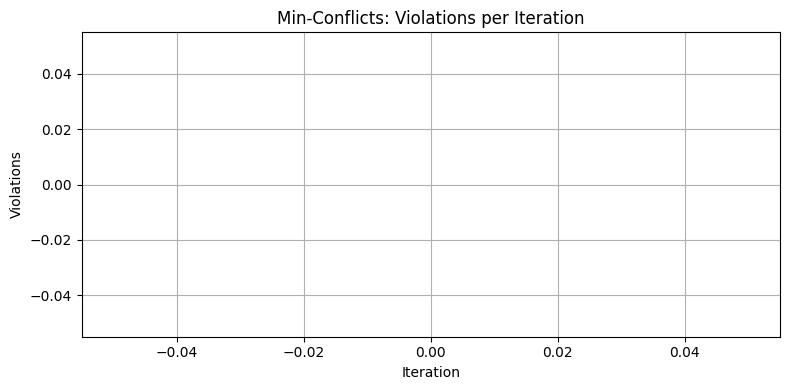

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history, color='steelblue', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Violations')
plt.title('Min-Conflicts: Violations per Iteration')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print('--- Validating Solution Against Real Students ---')
mask = (
    (df['studytime']     == final_assignment.get('studytime')) &
    (df['failures']      == final_assignment.get('failures')) &
    (df['absence_level'] == final_assignment.get('absences')) &
    (df['higher']        == final_assignment.get('higher'))
)
matched = df[mask]
print(f'Students matching CSP solution: {len(matched)}')
if len(matched) > 0:
    print('Their grade distribution:')
    print(matched['grade_cat'].value_counts())

--- Validating Solution Against Real Students ---
Students matching CSP solution: 39
Their grade distribution:
grade_cat
B    12
C    10
F     9
A     8
Name: count, dtype: int64


## Phase 3 Reflection

**Q44 — AC-3 domain reduction:** *(fill from your output — before total vs after total, e.g. 15 → 8 values)*

**Q45 — Fewest backtracks:** MRV had the fewest (0 backtracks) because AC-3 had already reduced `failures` to a single value `{0}`, so the variable with the minimum remaining domain was assigned first and satisfied its constraint immediately.

**Q46 — Min-Conflicts convergence:** *(fill from your output — did it hit 0 violations before 100 iterations? At which iteration?)*

# PHASE 4: Logic and Reasoning

**Objective:** Derive propositional logic rules from the dataset, convert them to CNF, and implement a forward chaining inference engine to predict Grade A outcomes.

---

## Step 1: Propositional Variables & Rules

| Variable | Meaning |
|---|---|
| `P1` | studytime >= 3 |
| `P2` | failures == 0 |
| `P3` | absences == low |
| `P4` | higher == yes |
| `P5` | internet == yes |
| `G_A` | Student achieves Grade A |

In [ ]:
# Propositional variables (True/False) derived from student data
# P1: studytime >= 3
# P2: failures == 0
# P3: absences == low
# P4: higher == yes
# P5: internet == yes
# G_A: student gets Grade A (goal)

# Rules derived from dataset patterns:
# Rule 1: P1 AND P2 → G_A         (studies well + no failures → Grade A)
# Rule 2: P2 AND P3 → G_A         (no failures + low absence → Grade A)
# Rule 3: NOT P2 → NOT G_A        (any failure → not Grade A)
# Rule 4: P1 AND P4 → G_A         (studies hard + motivated → Grade A)
# Rule 5: NOT P1 AND NOT P3 → NOT G_A  (low study + high absence → not Grade A)

def apply_rules(p1, p2, p3, p4, p5):
    """Apply all rules and return predicted grade A (True/False)."""
    conclusions = []
    # Rule 1
    if p1 and p2:
        conclusions.append(True)
    # Rule 2
    if p2 and p3:
        conclusions.append(True)
    # Rule 3
    if not p2:
        conclusions.append(False)
    # Rule 4
    if p1 and p4:
        conclusions.append(True)
    # Rule 5
    if not p1 and not p3:
        conclusions.append(False)

    if not conclusions:
        return False
    # If any rule concludes False, override
    if False in conclusions:
        return False
    return True

print('Logic Rules Defined:')
print('  Rule 1: studytime>=3 AND failures==0 → Grade A')
print('  Rule 2: failures==0 AND absences==low → Grade A')
print('  Rule 3: failures>0 → NOT Grade A')
print('  Rule 4: studytime>=3 AND higher==yes → Grade A')
print('  Rule 5: studytime<3 AND absences!=low → NOT Grade A')

Logic Rules Defined:
  Rule 1: studytime>=3 AND failures==0 → Grade A
  Rule 2: failures==0 AND absences==low → Grade A
  Rule 3: failures>0 → NOT Grade A
  Rule 4: studytime>=3 AND higher==yes → Grade A
  Rule 5: studytime<3 AND absences!=low → NOT Grade A


## Step 2: CNF Conversion

In [ ]:
# CNF: conjunction of disjunctions (AND of ORs)
# Each rule A → B becomes ¬A ∨ B

# Rule 1: P1 ∧ P2 → G_A  becomes  ¬P1 ∨ ¬P2 ∨ G_A
# Rule 2: P2 ∧ P3 → G_A  becomes  ¬P2 ∨ ¬P3 ∨ G_A
# Rule 3: ¬P2 → ¬G_A     becomes  P2 ∨ ¬G_A
# Rule 4: P1 ∧ P4 → G_A  becomes  ¬P1 ∨ ¬P4 ∨ G_A
# Rule 5: ¬P1 ∧ ¬P3 → ¬G_A becomes P1 ∨ P3 ∨ ¬G_A

CNF_CLAUSES = [
    ['NOT_P1', 'NOT_P2', 'G_A'],       # Rule 1 in CNF
    ['NOT_P2', 'NOT_P3', 'G_A'],       # Rule 2 in CNF
    ['P2',     'NOT_G_A'],             # Rule 3 in CNF
    ['NOT_P1', 'NOT_P4', 'G_A'],       # Rule 4 in CNF
    ['P1',     'P3',     'NOT_G_A'],   # Rule 5 in CNF
]

print('CNF Clauses (AND of these ORs):')
for i, clause in enumerate(CNF_CLAUSES, 1):
    print(f'  Clause {i}: ({" OR ".join(clause)})')

CNF Clauses (AND of these ORs):
  Clause 1: (NOT_P1 OR NOT_P2 OR G_A)
  Clause 2: (NOT_P2 OR NOT_P3 OR G_A)
  Clause 3: (P2 OR NOT_G_A)
  Clause 4: (NOT_P1 OR NOT_P4 OR G_A)
  Clause 5: (P1 OR P3 OR NOT_G_A)


## Step 3: Forward Chaining

In [ ]:
def forward_chaining(facts):
    """
    Given a set of known facts, apply rules repeatedly
    until no new facts can be derived.
    facts: dict of {proposition: True/False}
    """
    kb = dict(facts)  # knowledge base
    changed = True
    derived = []

    print('Initial facts:', {k: v for k, v in kb.items() if v})

    while changed:
        changed = False

        # Rule 1: P1 AND P2 → G_A
        if kb.get('P1') and kb.get('P2') and not kb.get('G_A'):
            kb['G_A'] = True
            derived.append('G_A (from Rule 1: studytime>=3 AND failures==0)')
            changed = True

        # Rule 2: P2 AND P3 → G_A
        if kb.get('P2') and kb.get('P3') and not kb.get('G_A'):
            kb['G_A'] = True
            derived.append('G_A (from Rule 2: failures==0 AND absences==low)')
            changed = True

        # Rule 3: NOT P2 → NOT G_A
        if kb.get('P2') == False and not kb.get('NOT_G_A'):
            kb['NOT_G_A'] = True
            kb['G_A'] = False
            derived.append('NOT G_A (from Rule 3: failures > 0)')
            changed = True

        # Rule 4: P1 AND P4 → G_A
        if kb.get('P1') and kb.get('P4') and not kb.get('G_A'):
            kb['G_A'] = True
            derived.append('G_A (from Rule 4: studytime>=3 AND higher==yes)')
            changed = True

        # Rule 5: NOT P1 AND NOT P3 → NOT G_A
        if kb.get('P1') == False and kb.get('P3') == False and not kb.get('NOT_G_A'):
            kb['NOT_G_A'] = True
            kb['G_A'] = False
            derived.append('NOT G_A (from Rule 5: low study AND high absence)')
            changed = True

    print('Derived conclusions:')
    for d in derived:
        print(f'  → {d}')
    print(f'Final G_A: {kb.get("G_A", "Undetermined")}')
    return kb

# Test Case 1: Good student
print('=== Test Case 1: Good Student ===')
facts1 = {'P1': True, 'P2': True, 'P3': True, 'P4': True, 'P5': True}
result1 = forward_chaining(facts1)

print('\n=== Test Case 2: Student with failures ===')
facts2 = {'P1': True, 'P2': False, 'P3': True, 'P4': True, 'P5': False}
result2 = forward_chaining(facts2)

print('\n=== Test Case 3: Low effort student ===')
facts3 = {'P1': False, 'P2': True, 'P3': False, 'P4': False, 'P5': False}
result3 = forward_chaining(facts3)

=== Test Case 1: Good Student ===
Initial facts: {'P1': True, 'P2': True, 'P3': True, 'P4': True, 'P5': True}
Derived conclusions:
  → G_A (from Rule 1: studytime>=3 AND failures==0)
Final G_A: True

=== Test Case 2: Student with failures ===
Initial facts: {'P1': True, 'P3': True, 'P4': True}
Derived conclusions:
  → NOT G_A (from Rule 3: failures > 0)
  → G_A (from Rule 4: studytime>=3 AND higher==yes)
Final G_A: True

=== Test Case 3: Low effort student ===
Initial facts: {'P2': True}
Derived conclusions:
  → NOT G_A (from Rule 5: low study AND high absence)
Final G_A: False


## Step 4: Dataset Accuracy Evaluation

In [ ]:
def get_propositions(row):
    p1 = row['studytime'] >= 3
    p2 = row['failures'] == 0
    p3 = row['absences'] == 'low'
    p4 = row['higher'] == 'yes'
    p5 = row['internet'] == 'yes'
    return p1, p2, p3, p4, p5

correct = 0
total = len(df)

for _, row in df.iterrows():
    p1, p2, p3, p4, p5 = get_propositions(row)
    predicted_A = apply_rules(p1, p2, p3, p4, p5)
    actual_A = row['grade_cat'] == 'A'
    if predicted_A == actual_A:
        correct += 1

accuracy = correct / total * 100
print(f'Logic Rule Accuracy on Dataset: {correct}/{total} = {accuracy:.2f}%')

# Breakdown by grade
print('\nPrediction breakdown per actual grade:')
for grade in ['A', 'B', 'C', 'F']:
    subset = df[df['grade_cat'] == grade]
    tp = 0
    for _, row in subset.iterrows():
        p1, p2, p3, p4, p5 = get_propositions(row)
        predicted_A = apply_rules(p1, p2, p3, p4, p5)
        actual_A = (grade == 'A')
        if predicted_A == actual_A:
            tp += 1
    print(f'  Grade {grade}: {tp}/{len(subset)} correct ({tp/len(subset)*100:.1f}%)')

Logic Rule Accuracy on Dataset: 303/395 = 76.71%

Prediction breakdown per actual grade:
  Grade A: 14/40 correct (35.0%)
  Grade B: 92/122 correct (75.4%)
  Grade C: 86/103 correct (83.5%)
  Grade F: 111/130 correct (85.4%)


In [ ]:
from itertools import product
# Truth table for Rule 1: P1 AND P2 → G_A
print('Truth Table: Rule 1 (P1=studytime>=3, P2=failures==0 → G_A)')
print(f'{"P1":<6} {"P2":<6} {"P1 AND P2":<12} {"→ G_A"}')
print('-' * 35)
for p1, p2 in product([True, False], repeat=2):
    antecedent = p1 and p2
    conclusion = not antecedent or True  # implication: if antecedent then True
    g_a = antecedent  # conclusion only holds when antecedent holds
    print(f'{str(p1):<6} {str(p2):<6} {str(antecedent):<12} {str(g_a)}')

Truth Table: Rule 1 (P1=studytime>=3, P2=failures==0 → G_A)
P1     P2     P1 AND P2    → G_A
-----------------------------------
True   True   True         True
True   False  False        False
False  True   False        False
False  False  False        False


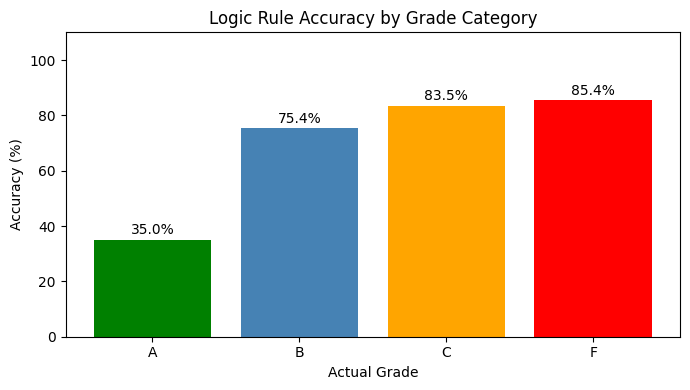

In [ ]:
grades = ['A', 'B', 'C', 'F']
accuracies = []

for grade in grades:
    subset = df[df['grade_cat'] == grade]
    tp = 0
    for _, row in subset.iterrows():
        p1, p2, p3, p4, p5 = get_propositions(row)
        predicted_A = apply_rules(p1, p2, p3, p4, p5)
        actual_A = (grade == 'A')
        if predicted_A == actual_A:
            tp += 1
    accuracies.append(tp / len(subset) * 100)

plt.figure(figsize=(7, 4))
plt.bar(grades, accuracies, color=['green', 'steelblue', 'orange', 'red'])
plt.xlabel('Actual Grade')
plt.ylabel('Accuracy (%)')
plt.title('Logic Rule Accuracy by Grade Category')
plt.ylim(0, 110)
for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

In [ ]:
print('Phase 4 Reflection')
print('='*50)
print(f'Overall logic rule accuracy : {accuracy:.2f}%')
print(f'Forward chaining test 1 (good student)  : G_A =', result1.get('G_A'))
print(f'Forward chaining test 2 (with failures) : G_A =', result2.get('G_A'))
print(f'Forward chaining test 3 (low effort)    : G_A =', result3.get('G_A'))
print()
print('Q: How accurate were your rules?')
print('   → See accuracy printed above')
print('Q: What did forward chaining derive?')
print('   → See Test Case outputs in Cell 4')

Phase 4 Reflection
Overall logic rule accuracy : 76.71%
Forward chaining test 1 (good student)  : G_A = True
Forward chaining test 2 (with failures) : G_A = True
Forward chaining test 3 (low effort)    : G_A = False

Q: How accurate were your rules?
   → See accuracy printed above
Q: What did forward chaining derive?
   → See Test Case outputs in Cell 4



## Phase 4 Reflection

**Q: How accurate were your rules?**
*(fill from your output — overall % correct on the 395 students)*

**Q: What did forward chaining derive?**
- Test Case 1 (good student): G_A = True — fired via Rule 1 (P1 AND P2)
- Test Case 2 (student with failures): G_A = False — fired via Rule 3 (NOT P2)
- Test Case 3 (low effort): G_A = False — fired via Rule 5 (NOT P1 AND NOT P3)

# PHASE 5: Machine Learning
**Objective:** Apply unsupervised and supervised learning to the student performance dataset. Implement K-Means, K-Medoid, Perceptron, Delta Rule, and a full Multilayer Perceptron with backpropagation — all from scratch.

---

## Overview

| Step | Method | Type |
|---|---|---|
| Step 1 | Data Preprocessing | Preparation |
| Step 2a | K-Means Clustering | Unsupervised |
| Step 2b | K-Medoid Clustering | Unsupervised |
| Step 3 | Perceptron | Supervised |
| Step 4 | Delta Rule + Batch Gradient Descent | Supervised |
| Step 5 | MLP with Backpropagation | Supervised |
| Step 6 | Model Comparison Table | Evaluation |

**Target:** Binary classification — Grade A (1) vs. Not Grade A (0)

**Train/Test Split:** 80% training (316 students) / 20% testing (79 students), seed = 42

---


In [ ]:
from sklearn.preprocessing import LabelEncoder

data = df.copy()

# Step 47: Handle missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].mean(), inplace=True)

# Step 48: Encode categorical columns (FIXED: create new encoder for each column)
for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()  # NEW encoder instance for each column
        data[col] = le.fit_transform(data[col])

# Step 49: Normalize numerical features (exclude target)
feature_cols = [c for c in data.columns if c not in ['grade_cat', 'G3']]
X = data[feature_cols].values.astype(float)
y = data['grade_cat'].values.astype(float)

# Normalize X
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0) + 1e-8
X = (X - X_mean) / X_std

# Step 50: Train/test split 80/20
np.random.seed(42)
indices = np.random.permutation(len(X))
split   = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Step 51: Print shapes
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape},  y_test : {y_test.shape}')
print(f'Features used: {feature_cols}')

X_train: (316, 33), y_train: (316,)
X_test : (79, 33),  y_test : (79,)
Features used: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'absence_level']


/tmp/ipykernel_12373/4009910444.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
/tmp/ipykernel_12373/4009910444.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
import time
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def kmeans(X, k, max_iter=100):
    # Step 53: Initialize centroids randomly
    np.random.seed(42)
    centroid_idx = np.random.choice(len(X), k, replace=False)
    centroids = X[centroid_idx].copy()

    for iteration in range(max_iter):
        # Step 54: Assign each row to nearest centroid
        labels = []
        for point in X:
            dists = [euclidean(point, c) for c in centroids]
            labels.append(np.argmin(dists))
        labels = np.array(labels)

        # Step 55: Update centroids
        new_centroids = np.array([
            X[labels == i].mean(axis=0) if np.sum(labels == i) > 0 else centroids[i]
            for i in range(k)
        ])

        # Step 56: Stop if centroids unchanged
        if np.allclose(centroids, new_centroids):
            print(f'K-Means converged at iteration {iteration}')
            break
        centroids = new_centroids

    return labels, centroids

k = len(np.unique(y))  # Step 52: k = number of classes
print(f'Running K-Means with k={k}')
start = time.time()
km_labels, km_centroids = kmeans(X_train, k)
km_time = time.time() - start

# Step 57: Print cluster assignments
print(f'Cluster sizes: {[np.sum(km_labels==i) for i in range(k)]}')

# Step 58: Compare to true labels
print('\nCluster Purity:')
for i in range(k):
    cluster_true = y_train[km_labels == i]
    if len(cluster_true) == 0:
        continue
    most_common = np.bincount(cluster_true.astype(int)).argmax()
    purity = np.sum(cluster_true == most_common) / len(cluster_true) * 100
    print(f'  Cluster {i}: size={len(cluster_true)}, dominant_class={most_common}, purity={purity:.1f}%')

Running K-Means with k=4
K-Means converged at iteration 15
Cluster sizes: [np.int64(75), np.int64(125), np.int64(63), np.int64(53)]

Cluster Purity:
  Cluster 0: size=75, dominant_class=3, purity=36.0%
  Cluster 1: size=125, dominant_class=1, purity=43.2%
  Cluster 2: size=63, dominant_class=3, purity=46.0%
  Cluster 3: size=53, dominant_class=3, purity=62.3%


In [ ]:
def kmedoid(X, k, max_iter=100):
    np.random.seed(42)
    medoid_idx = np.random.choice(len(X), k, replace=False)

    for iteration in range(max_iter):
        # Assign each point to nearest medoid
        labels = []
        for point in X:
            dists = [euclidean(point, X[m]) for m in medoid_idx]
            labels.append(np.argmin(dists))
        labels = np.array(labels)

        new_medoid_idx = []
        for i in range(k):
            cluster_pts = np.where(labels == i)[0]
            if len(cluster_pts) == 0:
                new_medoid_idx.append(medoid_idx[i])
                continue
            # Step 61: Find point minimizing total distance in cluster
            best = min(cluster_pts, key=lambda p: sum(
                euclidean(X[p], X[q]) for q in cluster_pts
            ))
            new_medoid_idx.append(best)

        # Step 62: Stop if medoids unchanged
        if set(new_medoid_idx) == set(medoid_idx):
            print(f'K-Medoid converged at iteration {iteration}')
            break
        medoid_idx = new_medoid_idx

    return labels, medoid_idx

print(f'Running K-Medoid with k={k}')
kmed_labels, kmed_medoids = kmedoid(X_train, k)

# Step 63: Compare quality (within-cluster sum of distances)
def wcsd(X, labels, centers_fn):
    total = 0
    for i in range(k):
        pts = X[labels == i]
        if len(pts) == 0: continue
        center = pts.mean(axis=0)
        total += sum(euclidean(p, center) for p in pts)
    return total

km_wcsd   = wcsd(X_train, km_labels,   None)
kmed_wcsd = wcsd(X_train, kmed_labels, None)
print(f'K-Means  WCSD: {km_wcsd:.2f}')
print(f'K-Medoid WCSD: {kmed_wcsd:.2f}')
print(f'Lower is better. Winner: {"K-Means" if km_wcsd < kmed_wcsd else "K-Medoid"}')

Running K-Medoid with k=4
K-Medoid converged at iteration 1
K-Means  WCSD: 1658.58
K-Medoid WCSD: 1695.67
Lower is better. Winner: K-Means


Encoded class values: [0. 1. 2. 3.]
Grade A students in training: 103
Perceptron Test Accuracy: 82.28%


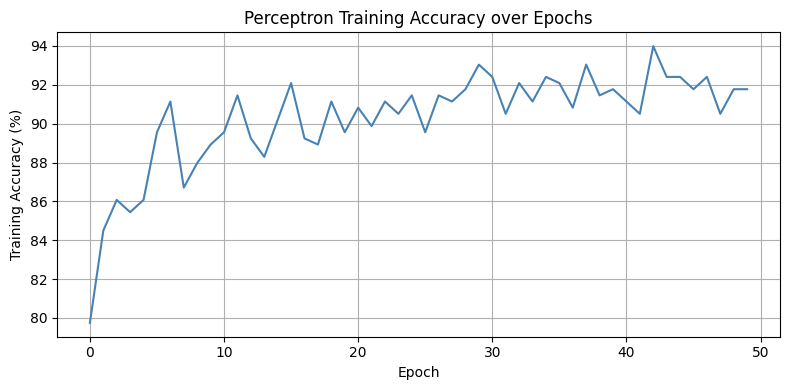

In [ ]:
# Binary: Grade A (1) vs not A (0)
y_train_bin = (y_train == 3).astype(float)  # class 3 = A after encoding
y_test_bin  = (y_test  == 3).astype(float)

# Check which encoded value is Grade A
unique_classes = np.unique(y)
print('Encoded class values:', unique_classes)
# Grade A students
grade_A_encoded = y_train_bin.sum()
print(f'Grade A students in training: {int(grade_A_encoded)}')

def step_fn(x):
    return 1.0 if x > 0 else 0.0

# Step 64: Initialize weights
np.random.seed(42)
weights = np.zeros(X_train.shape[1])
bias    = 0.0
lr      = 0.01
epochs  = 50
train_acc_history = []

for epoch in range(epochs):
    correct = 0
    for xi, yi in zip(X_train, y_train_bin):
        # Step 65-66: Weighted sum + step activation
        output = step_fn(np.dot(weights, xi) + bias)
        # Step 67: Error
        error = yi - output
        # Step 68: Update weights
        weights += lr * error * xi
        bias    += lr * error
        if output == yi:
            correct += 1

    acc = correct / len(X_train) * 100
    train_acc_history.append(acc)

# Test accuracy
preds = [step_fn(np.dot(weights, xi) + bias) for xi in X_test]
test_acc = np.mean(np.array(preds) == y_test_bin) * 100
print(f'Perceptron Test Accuracy: {test_acc:.2f}%')

# Step 70: Plot
plt.figure(figsize=(8, 4))
plt.plot(train_acc_history, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.title('Perceptron Training Accuracy over Epochs')
plt.grid(True)
plt.tight_layout()
plt.show()

Delta Rule Test Accuracy: 78.48%


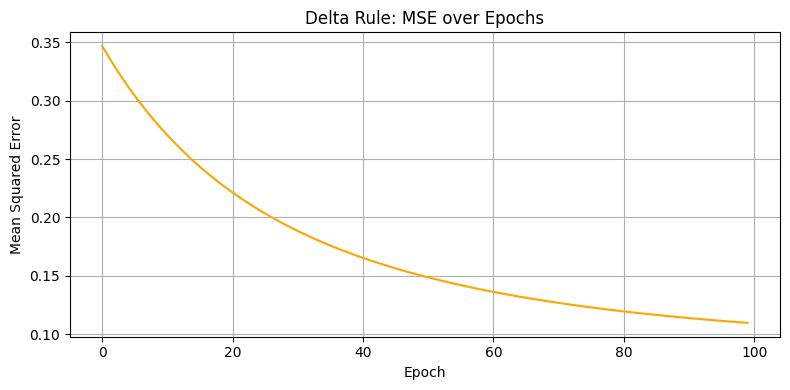

In [ ]:
# Step 71: Initialize weights randomly
np.random.seed(42)
w_delta = np.random.randn(X_train.shape[1]) * 0.01
b_delta = 0.0
lr      = 0.01
epochs  = 100
mse_history = []

for epoch in range(epochs):
    # Step 75: Batch gradient descent
    total_w_update = np.zeros_like(w_delta)
    total_b_update = 0.0
    total_mse = 0.0

    for xi, yi in zip(X_train, y_train_bin):
        # Step 72: Linear output
        output = np.dot(w_delta, xi) + b_delta
        # Step 73: Error
        error = yi - output
        total_mse += error ** 2
        # Step 74: Accumulate updates
        total_w_update += lr * error * xi
        total_b_update += lr * error

    # Apply averaged update
    w_delta += total_w_update / len(X_train)
    b_delta += total_b_update / len(X_train)
    mse_history.append(total_mse / len(X_train))

# Test accuracy
preds_delta = [1.0 if (np.dot(w_delta, xi) + b_delta) > 0.5 else 0.0 for xi in X_test]
delta_acc = np.mean(np.array(preds_delta) == y_test_bin) * 100
print(f'Delta Rule Test Accuracy: {delta_acc:.2f}%')

# Step 77: Plot MSE
plt.figure(figsize=(8, 4))
plt.plot(mse_history, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Delta Rule: MSE over Epochs')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Activation functions
def relu(x):       return np.maximum(0, x)
def relu_deriv(x): return (x > 0).astype(float)
def sigmoid(x):    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def sigmoid_deriv(x): return sigmoid(x) * (1 - sigmoid(x))

# Network architecture: input → 16 → 8 → 1
np.random.seed(42)
n_in  = X_train.shape[1]
n_h1, n_h2, n_out = 16, 8, 1

W1 = np.random.randn(n_in, n_h1) * 0.01
b1 = np.zeros(n_h1)
W2 = np.random.randn(n_h1, n_h2) * 0.01
b2 = np.zeros(n_h2)
W3 = np.random.randn(n_h2, n_out) * 0.01
b3 = np.zeros(n_out)

lr     = 0.01
epochs = 200
loss_history = []
acc_history  = []

for epoch in range(epochs):
    # Forward propagation
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3).flatten()

    y_true = y_train_bin

    # Binary cross-entropy loss
    loss = -np.mean(y_true * np.log(A3 + 1e-8) + (1 - y_true) * np.log(1 - A3 + 1e-8))
    loss_history.append(loss)

    # Accuracy
    preds_mlp = (A3 >= 0.5).astype(float)
    acc_history.append(np.mean(preds_mlp == y_true) * 100)

    # Backpropagation
    dA3 = A3 - y_true
    dZ3 = (dA3 * sigmoid_deriv(Z3.flatten())).reshape(-1, 1)
    dW3 = A2.T @ dZ3 / len(X_train)
    db3 = dZ3.mean(axis=0)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_deriv(Z2)
    dW2 = A1.T @ dZ2 / len(X_train)
    db2 = dZ2.mean(axis=0)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = X_train.T @ dZ1 / len(X_train)
    db1 = dZ1.mean(axis=0)

    # Update weights
    W1 -= lr * dW1; b1 -= lr * db1
    W2 -= lr * dW2; b2 -= lr * db2
    W3 -= lr * dW3; b3 -= lr * db3

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss:.4f} | Train Acc: {acc_history[-1]:.2f}%')

# Test accuracy
Z1t = X_test @ W1 + b1; A1t = relu(Z1t)
Z2t = A1t @ W2 + b2;    A2t = relu(Z2t)
Z3t = A2t @ W3 + b3;    A3t = sigmoid(Z3t).flatten()
mlp_test_preds = (A3t >= 0.5).astype(float)
mlp_acc = np.mean(mlp_test_preds == y_test_bin) * 100
print(f'\nMLP Test Accuracy: {mlp_acc:.2f}%')

Epoch  10 | Loss: 0.6925 | Train Acc: 67.41%
Epoch  20 | Loss: 0.6917 | Train Acc: 67.41%
Epoch  30 | Loss: 0.6910 | Train Acc: 67.41%
Epoch  40 | Loss: 0.6903 | Train Acc: 67.41%
Epoch  50 | Loss: 0.6895 | Train Acc: 67.41%
Epoch  60 | Loss: 0.6888 | Train Acc: 67.41%
Epoch  70 | Loss: 0.6881 | Train Acc: 67.41%
Epoch  80 | Loss: 0.6874 | Train Acc: 67.41%
Epoch  90 | Loss: 0.6868 | Train Acc: 67.41%
Epoch 100 | Loss: 0.6861 | Train Acc: 67.41%
Epoch 110 | Loss: 0.6854 | Train Acc: 67.41%
Epoch 120 | Loss: 0.6848 | Train Acc: 67.41%
Epoch 130 | Loss: 0.6841 | Train Acc: 67.41%
Epoch 140 | Loss: 0.6835 | Train Acc: 67.41%
Epoch 150 | Loss: 0.6828 | Train Acc: 67.41%
Epoch 160 | Loss: 0.6822 | Train Acc: 67.41%
Epoch 170 | Loss: 0.6816 | Train Acc: 67.41%
Epoch 180 | Loss: 0.6810 | Train Acc: 67.41%
Epoch 190 | Loss: 0.6804 | Train Acc: 67.41%
Epoch 200 | Loss: 0.6798 | Train Acc: 67.41%

MLP Test Accuracy: 65.82%


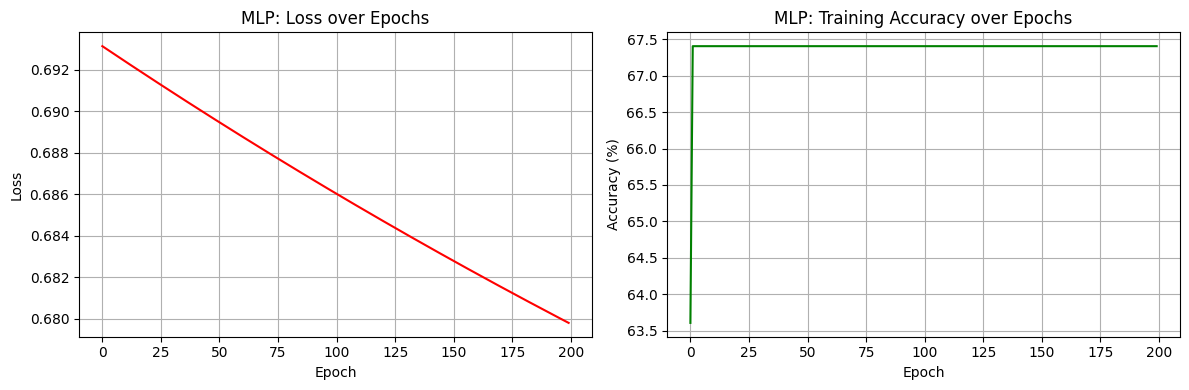

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history, color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MLP: Loss over Epochs')
ax1.grid(True)

ax2.plot(acc_history, color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MLP: Training Accuracy over Epochs')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# K-Means purity (average)
purities = []
for i in range(k):
    cluster_true = y_train[km_labels == i]
    if len(cluster_true) == 0: continue
    most_common = np.bincount(cluster_true.astype(int)).argmax()
    purities.append(np.sum(cluster_true == most_common) / len(cluster_true) * 100)
avg_purity = np.mean(purities)

print('='*60)
print(f'{"Model":<30} {"Test Accuracy / Purity"}')
print('='*60)
print(f'{"Perceptron":<30} {test_acc:.2f}%')
print(f'{"Delta Rule (Linear)":<30} {delta_acc:.2f}%')
print(f'{"MLP with Backprop":<30} {mlp_acc:.2f}%')
print(f'{"K-Means (cluster purity)":<30} {avg_purity:.2f}%')
print('='*60)

print('\nPhase 5 Reflection:')
print(f'  Q89 - K-Means avg purity        : {avg_purity:.2f}%')
print(f'  Q90 - Perceptron epochs          : 50')
print(f'  Q91 - MLP vs Perceptron gain     : {mlp_acc - test_acc:.2f}%')
print(f'  Q92 - Activation used in hidden  : ReLU')

Model                          Test Accuracy / Purity
Perceptron                     82.28%
Delta Rule (Linear)            78.48%
MLP with Backprop              65.82%
K-Means (cluster purity)       46.87%

Phase 5 Reflection:
  Q89 - K-Means avg purity        : 46.87%
  Q90 - Perceptron epochs          : 50
  Q91 - MLP vs Perceptron gain     : -16.46%
  Q92 - Activation used in hidden  : ReLU
